Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 47ms/step - accuracy: 0.4796 - loss: 1.4514 - val_accuracy: 0.5842 - val_loss: 1.1792
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6166 - loss: 1.1011 - val_accuracy: 0.6482 - val_loss: 1.0406
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.6680 - loss: 0.9599 - val_accuracy: 0.6661 - val_loss: 0.9702
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6992 - loss: 0.8689 - val_accuracy: 0.6752 - val_loss: 0.9694
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.7236 - loss: 0.7960 - val_accuracy: 0.7038 - val_loss: 0.8736
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 44ms/step - accuracy: 0.7414 - loss: 0.7426 - val_accuracy: 0.6859 - val_loss: 0.9174
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 45ms/step - accuracy: 0.7593 - loss: 0.6957 - val_accuracy: 0.7018 - val_loss: 0.8794
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.7729 -

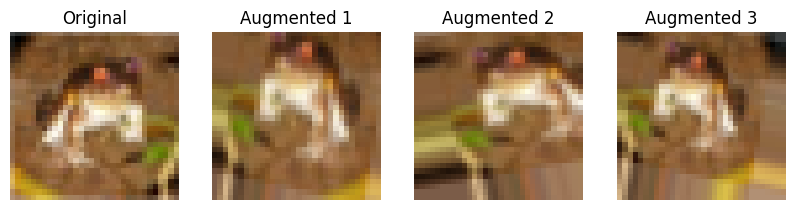

In [4]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator


(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()


train_images, test_images = train_images / 255.0, test_images / 255.0


model = models.Sequential([

    layers.Input(shape=(32, 32, 3)),


    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),


    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),


    layers.Flatten(),


    layers.Dense(64, activation='relu'),


    layers.Dense(10)
])


model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


model.fit(train_images, train_labels, epochs=10,
          validation_data=(test_images, test_labels))


test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nFinal Test Accuracy: {test_acc:.4f}')

import matplotlib.pyplot as plt

# Define the ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

# 1. Take one image from the training set
image = train_images[0]
image_reshaped = image.reshape((1,) + image.shape)

# 2. Generate augmented variations
# This uses the 'datagen' object we defined earlier
plt.figure(figsize=(10, 10))
plt.subplot(1, 4, 1)
plt.title("Original")
plt.imshow(image)
plt.axis('off')

# Show 3 augmented versions
i = 2
for batch in datagen.flow(image_reshaped, batch_size=1):
    plt.subplot(1, 4, i)
    plt.title(f"Augmented {i-1}")
    plt.imshow(batch[0])
    plt.axis('off')
    i += 1
    if i > 4:
        break
plt.show()